<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_04_Aluno_Backpropagation_Otimizacao_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 4 – Backpropagation e Otimização

## Tema da aula
**Loss Functions, Backpropagation, Gradiente Descendente, SGD e Adam**

## Capacidades trabalhadas
- Construir redes neurais artificiais.
- Demonstrar atenção a detalhes.

## Objetivos da aula - versão do aluno
Ao final desta aula, o aluno deverá ser capaz de:
1. Explicar o papel da função de perda no treinamento de redes neurais.
2. Interpretar o processo de backpropagation como o cálculo do impacto de cada peso no erro do modelo.
3. Implementar, de forma didática, a atualização de pesos usando gradiente descendente.
4. Comparar o comportamento dos otimizadores SGD e Adam.
5. Analisar graficamente a evolução da loss durante o treinamento.

## Situação contextualizada
Uma indústria monitora motores elétricos por meio de sensores de temperatura, vibração e corrente. A equipe deseja treinar um modelo neural simples para classificar se a condição do motor indica **operação normal** ou **risco de falha**.

Nesta aula, o foco não é apenas obter boa acurácia, mas compreender **como o modelo aprende**, ou seja, como os pesos são ajustados a partir do erro.

## 1. Como uma rede neural aprende?

Complete a explicação durante a aula:

1. **Forward propagation:** Processo em que os dados de entrada percorrem a rede neural camada por camada, sendo multiplicados pelos pesos, somados aos bias e transformados por funções de ativação, gerando uma saída prevista.
2. **Loss:** Métrica que mede o erro entre a saída prevista pelo modelo e o valor real esperado, quantificando o desempenho da rede.
3. **Backpropagation:** Algoritmo que calcula o gradiente do erro em relação aos pesos da rede, propagando o erro da saída para as camadas anteriores, permitindo ajustar os parâmetros.
4. **Otimização:** Processo de atualização dos pesos e bias com base nos gradientes calculados, utilizando algoritmos como Gradiente Descendente, para minimizar a função de loss

Em suas palavras, explique:

> O que significa dizer que o modelo está “ajustando os pesos”?  
> Significa que a rede neural está modificando os valores dos pesos das conexões entre os neurônios para reduzir o erro das previsões, aprendendo padrões nos dados e melhorando sua precisão ao longo do treinamento.

In [1]:
# Importe as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Carregamento do dataset industrial

Variáveis de entrada:

- temperatura do motor;
- vibração;
- corrente elétrica.

Variável alvo:

- risco de falha.

In [5]:
# Complete o nome do arquivo CSV
df = pd.read_csv('/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula4_backprop_otimizacao_industrial.csv')

# Visualize as primeiras linhas
df.head(5)

,temperatura_motor_c,vibracao_mm_s,corrente_a,risco_falha
0,75.05,2.91,8.18,0
1,61.60,3.52,9.06,0
2,79.50,3.43,9.12,1
3,81.41,1.79,10.75,1
4,52.49,3.32,7.92,0


In [6]:
# Exiba o formato do dataset e a distribuição da variável alvo
print('Formato do dataset:', df.shape)
print('Distribuição da variável alvo:')
print(df['risco_falha'].value_counts())

df.describe()

Formato do dataset: (220, 4)
Distribuição da variável alvo:
risco_falha
1    111
0    109
Name: count, dtype: int64


,temperatura_motor_c,vibracao_mm_s,corrente_a,risco_falha
count,220.000000,220.000000,220.000000,220.000000
mean,71.629773,3.193000,8.460318,0.504545
std,8.836305,1.314687,1.724866,0.501120
min,50.680000,0.500000,4.500000,0.000000
25%,65.370000,2.290000,7.265000,0.000000
50%,71.480000,3.270000,8.430000,1.000000
75%,77.392500,4.000000,9.490000,1.000000
max,101.140000,6.980000,12.920000,1.000000


## 3. Visualização inicial

Gere gráficos de dispersão para analisar visualmente a relação entre as variáveis.

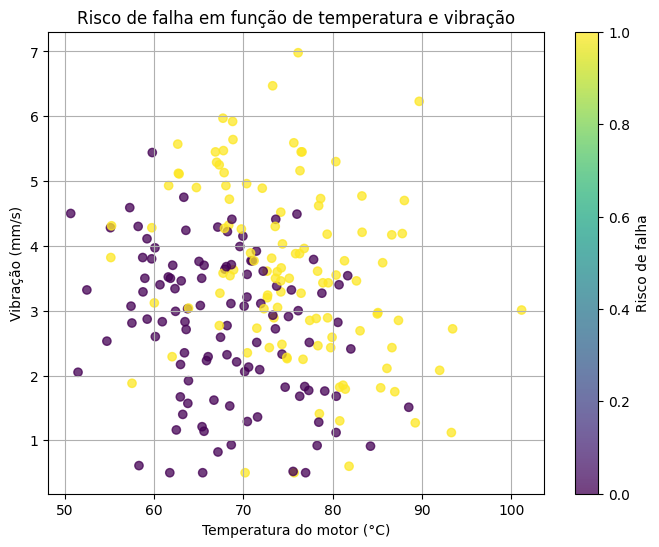

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(df['temperatura_motor_c'], df['vibracao_mm_s'], c=df['risco_falha'], alpha=0.75)
plt.xlabel('Temperatura do motor (°C)')
plt.ylabel('Vibração (mm/s)')
plt.title('Risco de falha em função de temperatura e vibração')
plt.colorbar(label='Risco de falha')
plt.grid(True)
plt.show()

## 4. Função de perda

Explique com suas palavras:

1. Para que serve uma função de perda?  
   Serve para medir o erro do modelo, comparando a saída prevista com o valor real, indicando o quanto a rede neural está errando.

2. O que significa uma loss alta?  
   Significa que o modelo está cometendo muitos erros, ou seja, suas previsões estão longe dos valores reais.

3. O que significa uma loss baixa?  
   Significa que o modelo está acertando mais, ou seja, suas previsões estão próximas dos valores reais.

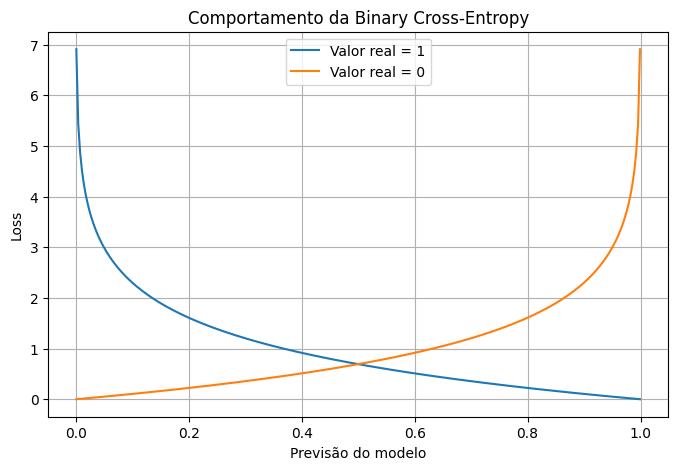

In [8]:
# Complete a construção do gráfico da Binary Cross-Entropy
predicoes = np.linspace(0.001, 0.999, 300)

loss_y1 = -np.log(predicoes)
loss_y0 = -np.log(1 - predicoes)

plt.figure(figsize=(8,5))
plt.plot(predicoes, loss_y1, label='Valor real = 1')
plt.plot(predicoes, loss_y0, label='Valor real = 0')
plt.xlabel('Previsão do modelo')
plt.ylabel('Loss')
plt.title('Comportamento da Binary Cross-Entropy')
plt.legend()
plt.grid(True)
plt.show()

## 5. Preparação dos dados

Separe as variáveis de entrada e a variável alvo. Em seguida, aplique padronização.

In [10]:
X = df[['temperatura_motor_c', 'vibracao_mm_s', 'corrente_a']].values
y = df['risco_falha'].values.reshape(-1, 1)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print('Formato dos dados de treino:', X_treino_scaled.shape)
print('Formato dos dados de teste:', X_teste_scaled.shape)

Formato dos dados de treino: (165, 3)
Formato dos dados de teste: (55, 3)


## 6. Backpropagation com classe em Python

Complete a classe abaixo para implementar o ciclo:

1. Forward propagation;
2. Cálculo da loss;
3. Backpropagation;
4. Atualização dos pesos.

In [11]:
class NeuronioSigmoideBackprop:
    def __init__(self, n_entradas, taxa_aprendizado=0.1):
        self.W = np.random.randn(n_entradas, 1) * 0.01
        self.b = 0.0
        self.taxa_aprendizado = taxa_aprendizado
        self.historico_loss = []
        self.historico_pesos = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.z = np.dot(X, self.W) + self.b
        self.y_pred = self.sigmoid(self.z)
        return self.y_pred

    def calcular_loss(self, y_real, y_pred):
        epsilon = 1e-8
        loss = -np.mean(y_real * np.log(y_pred + epsilon) + (1 - y_real) * np.log(1 - y_pred + epsilon))
        return loss

    def backward(self, X, y_real):
        m = X.shape[0]
        dz = self.y_pred - y_real
        dW = np.dot(X.T, dz) / m
        db = np.sum(dz) / m
        return dW, db

    def atualizar_pesos(self, dW, db):
        self.W = self.W - self.taxa_aprendizado * dW
        self.b = self.b - self.taxa_aprendizado * db

    def treinar(self, X, y, epocas=100):
        for epoca in range(epocas):
            y_pred = self.forward(X)
            loss = self.calcular_loss(y, y_pred)
            dW, db = self.backward(X, y)
            self.atualizar_pesos(dW, db)

            self.historico_loss.append(loss)
            self.historico_pesos.append(self.W.flatten().copy())

            if epoca % 20 == 0:
                print(f'Época {epoca:03d} | Loss: {loss:.4f}')

    def prever_probabilidade(self, X):
        return self.forward(X)

    def prever_classe(self, X, limiar=0.5):
        return (self.prever_probabilidade(X) >= limiar).astype(int)

In [12]:
# Crie e treine o modelo manual
modelo_manual = NeuronioSigmoideBackprop(n_entradas=3, taxa_aprendizado=0.25)
modelo_manual.treinar(X_treino_scaled, y_treino, epocas=201)

Época 000 | Loss: 0.6906
Época 020 | Loss: 0.4103
Época 040 | Loss: 0.3471
Época 060 | Loss: 0.3194
Época 080 | Loss: 0.3041
Época 100 | Loss: 0.2945
Época 120 | Loss: 0.2880
Época 140 | Loss: 0.2834
Época 160 | Loss: 0.2801
Época 180 | Loss: 0.2776
Época 200 | Loss: 0.2756


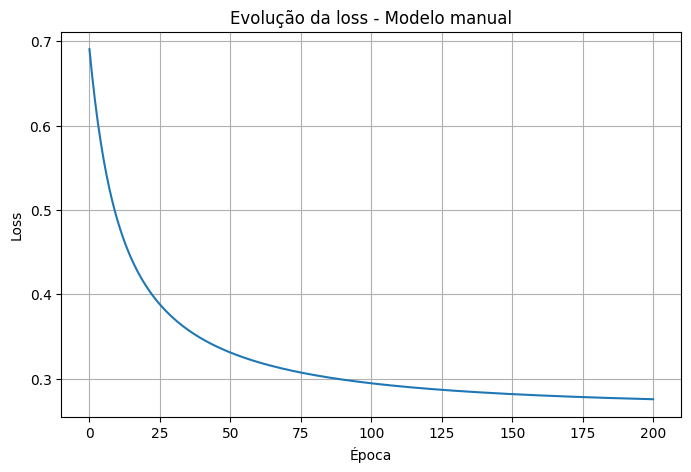

In [13]:
# Plote a evolução da loss
plt.figure(figsize=(8,5))
plt.plot(modelo_manual.historico_loss)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Evolução da loss - Modelo manual')
plt.grid(True)
plt.show()

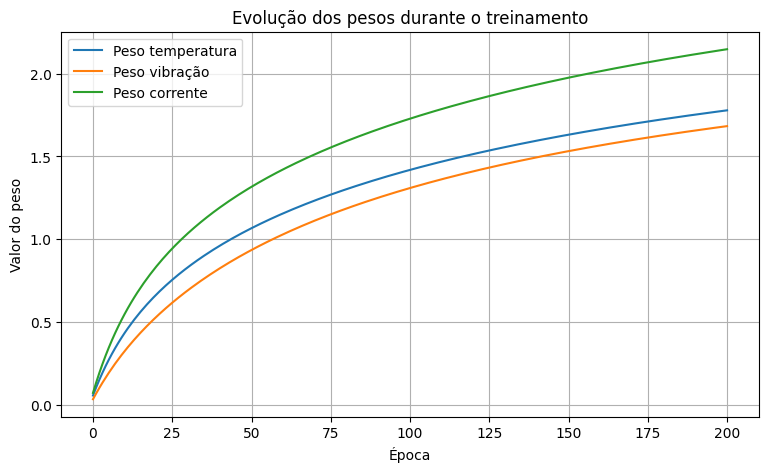

In [14]:
# Plote a evolução dos pesos
pesos = np.array(modelo_manual.historico_pesos)

plt.figure(figsize=(9,5))
plt.plot(pesos[:,0], label='Peso temperatura')
plt.plot(pesos[:,1], label='Peso vibração')
plt.plot(pesos[:,2], label='Peso corrente')
plt.xlabel('Época')
plt.ylabel('Valor do peso')
plt.title('Evolução dos pesos durante o treinamento')
plt.legend()
plt.grid(True)
plt.show()

## 7. Interpretação dos pesos

Após o treinamento, responda:

1. Qual variável teve maior peso absoluto?  
   A variável com maior peso absoluto é aquela que mais influencia a saída do modelo, pois seu valor (positivo ou negativo) tem maior impacto no resultado final.

2. O que significa um peso positivo?  
   Significa que a variável contribui diretamente para aumentar o valor da saída: quanto maior o valor da entrada, maior tende a ser a saída.

3. O que significa um peso negativo?  
   Significa que a variável contribui de forma inversa: quanto maior o valor da entrada, menor tende a ser a saída.

In [15]:
y_pred_manual = modelo_manual.prever_classe(X_teste_scaled)

print('Acurácia:', accuracy_score(y_teste, y_pred_manual))
print(confusion_matrix(y_teste, y_pred_manual))
print(classification_report(y_teste, y_pred_manual))

Acurácia: 0.8909090909090909
[[25  2]
 [ 4 24]]
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.92      0.86      0.89        28

    accuracy                           0.89        55
   macro avg       0.89      0.89      0.89        55
weighted avg       0.89      0.89      0.89        55



## 8. Fronteira de decisão

A fronteira de decisão mostra a separação criada pelo modelo entre as classes.

Complete a função abaixo para visualizar essa separação.

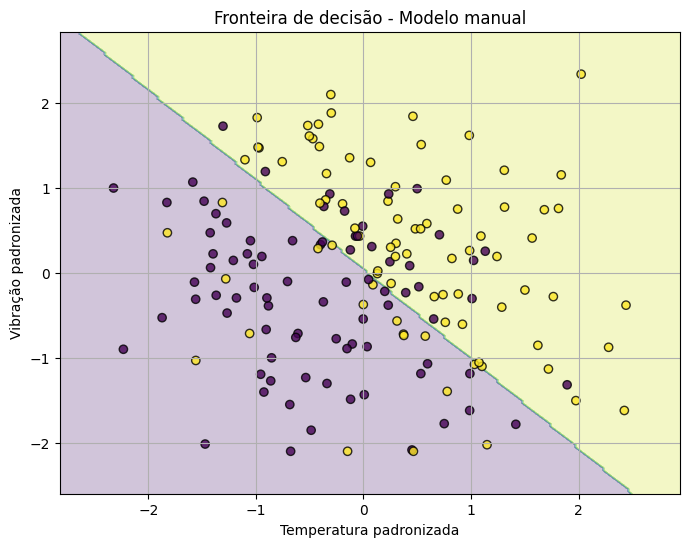

In [16]:
def plotar_fronteira_decisao(modelo, X_scaled, y, titulo):
    x_min, x_max = X_scaled[:,0].min() - 0.5, X_scaled[:,0].max() + 0.5
    y_min, y_max = X_scaled[:,1].min() - 0.5, X_scaled[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    corrente_media = np.zeros_like(xx.ravel())
    grid = np.c_[xx.ravel(), yy.ravel(), corrente_media]
    Z = modelo.prever_classe(grid).reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y.ravel(), edgecolor='k', alpha=0.8)
    plt.xlabel('Temperatura padronizada')
    plt.ylabel('Vibração padronizada')
    plt.title(titulo)
    plt.grid(True)
    plt.show()

plotar_fronteira_decisao(modelo_manual, X_treino_scaled, y_treino, 'Fronteira de decisão - Modelo manual')

## 9. Comparação entre SGD e Adam com TensorFlow

Agora utilizaremos TensorFlow para comparar os otimizadores.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

print('Versão do TensorFlow:', tf.__version__)

Versão do TensorFlow: 2.20.0


In [18]:
def criar_modelo_tf(otimizador):
    modelo = Sequential([
        Dense(8, activation='relu', input_shape=(3,)),
        Dense(4, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=otimizador,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelo

In [19]:
# Treinamento com SGD
modelo_sgd = criar_modelo_tf(SGD(learning_rate=0.05))

historico_sgd = modelo_sgd.fit(
    X_treino_scaled, y_treino,
    validation_data=(X_teste_scaled, y_teste),
    epochs=80,
    batch_size=16,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Treinamento com Adam
modelo_adam = criar_modelo_tf(Adam(learning_rate=0.01))

historico_adam = modelo_adam.fit(
    X_treino_scaled, y_treino,
    validation_data=(X_teste_scaled, y_teste),
    epochs=80,
    batch_size=16,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


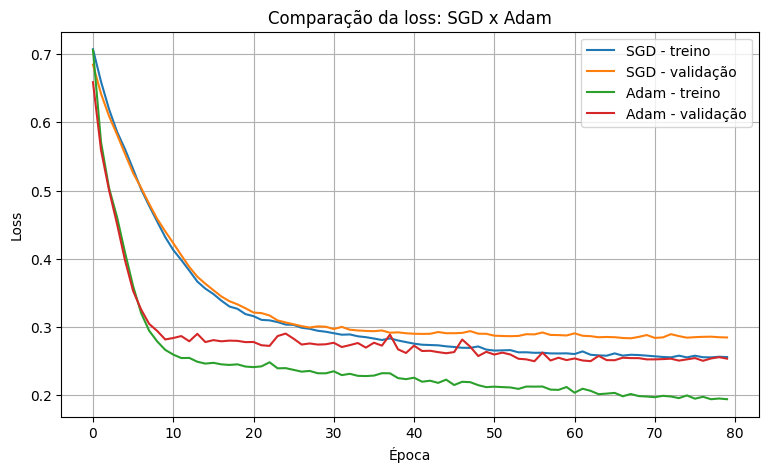

In [21]:
# Compare graficamente a loss dos dois otimizadores
plt.figure(figsize=(9,5))
plt.plot(historico_sgd.history['loss'], label='SGD - treino')
plt.plot(historico_sgd.history['val_loss'], label='SGD - validação')
plt.plot(historico_adam.history['loss'], label='Adam - treino')
plt.plot(historico_adam.history['val_loss'], label='Adam - validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Comparação da loss: SGD x Adam')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Monte uma tabela comparativa final
loss_sgd, acc_sgd = modelo_sgd.evaluate(X_teste_scaled, y_teste, verbose=0)
loss_adam, acc_adam = modelo_adam.evaluate(X_teste_scaled, y_teste, verbose=0)

comparacao = pd.DataFrame({
    'Otimizador': ['SGD', 'Adam'],
    'Loss de teste': [loss_sgd, loss_adam],
    'Acurácia de teste': [acc_sgd, acc_adam]
})

comparacao

,Otimizador,Loss de teste,Acurácia de teste
0,SGD,0.284764,0.909091
1,Adam,0.253726,0.890909


## 10. Relatório técnico comparativo

Responda com base nos gráficos e resultados obtidos.

1. Qual otimizador apresentou menor loss de validação?  
   Adam

2. Qual otimizador apresentou maior acurácia de teste?  
   SGD

3. O comportamento da loss foi estável ou oscilou?  
   Oscilou levemente no início do treinamento, mas tende a se estabilizar conforme o modelo aprende e converge para valores menores de erro.

4. Explique o que o backpropagation faz.  
   O backpropagation calcula o erro da saída e o propaga de volta pelas camadas da rede, determinando como cada peso contribuiu para o erro e quanto ele deve ser ajustado.

5. Explique o papel do gradiente descendente.  
   O gradiente descendente atualiza os pesos do modelo na direção que reduz a loss, utilizando os gradientes calculados para minimizar o erro ao longo do treinamento.

6. Em uma aplicação industrial, por que acompanhar a loss é importante?  
   Porque permite monitorar o desempenho do modelo ao longo do tempo, identificar problemas como overfitting ou underfitting e garantir que o modelo continue aprendendo corretamente e gerando previsões confiáveis.

## Checklist de entrega

- [ ] Dataset carregado corretamente.
- [ ] Gráfico da função de perda gerado.
- [ ] Classe manual de backpropagation completada.
- [ ] Modelo manual treinado.
- [ ] Gráficos de loss e pesos gerados.
- [ ] Fronteira de decisão gerada.
- [ ] Modelos TensorFlow com SGD e Adam treinados.
- [ ] Relatório técnico comparativo preenchido.